# 05s — Evaluate on the held-out test city

Loads `ckpt/best.pt` (selected on Rome val) and evaluates on the **test** split
(Cairo — never seen in training or checkpoint selection). All metrics are in
physical LST units (de-z-scored) and compared against the **persistence
baseline** (most recent WGAST raster in each sample's own 10-day history,
ROADMAP §3.5): persistence is the "no model" floor the UNet has to beat.

Set `SPLIT = "val"` to look at Rome during development without touching Cairo.

In [9]:
# --- Configuration -------------------------------------------------------------
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from cities import DATA_ROOT
from dataset import WGASTSurrogateDataset
from model_unet import ConditionalUNet
from losses import ssim

MANIFEST = DATA_ROOT / "samples_all" / "manifest.parquet"
CKPT     = DATA_ROOT / "ckpt" / "best.pt"
SPLIT    = "val"   # Cairo. Use "val" (Rome) during development.

device = ("cuda" if torch.cuda.is_available()
          else "mps" if torch.backends.mps.is_available() else "cpu")
print("device:", device, "| split:", SPLIT)

device: mps | split: val


In [10]:
# --- Helpers ---------------------------------------------------------------------
def metrics(pred, target, data_range):
    diff = pred - target
    mse  = (diff ** 2).mean()
    return {
        "rmse": mse.sqrt().item(),
        "mae":  diff.abs().mean().item(),
        "bias": diff.mean().item(),
        "psnr": (10 * torch.log10(data_range ** 2 / mse.clamp_min(1e-12))).item(),
        "ssim": ssim(pred, target, data_range=data_range).item(),
    }


def pad16(x):
    """Pad spatial dims to next multiple of 16. Returns (padded, h, w)."""
    _, _, h, w = x.shape
    ph = (16 - h % 16) % 16
    pw = (16 - w % 16) % 16
    return F.pad(x, (0, pw, 0, ph)), h, w


def persistence_from_history(npz_path):
    """ROADMAP §3.5 baseline: the most recent populated WGAST slot in the
    sample's own 10-day history (slot j=0 is d-1; WGAST ch=9j+7, mask ch=9j+8).
    Raw npz is in physical units already."""
    sp = np.load(npz_path)["spatial"]
    for j in range(10):
        if sp[9 * j + 8].any():
            return torch.from_numpy(sp[9 * j + 7].copy())[None, None]
    return None  # cannot happen for kept samples (N=1 filter #2)

In [11]:
# --- Run model + persistence over the split ----------------------------------------
ds = WGASTSurrogateDataset(MANIFEST, split=SPLIT)
if len(ds) == 0:
    raise RuntimeError(
        f"split '{SPLIT}' is empty -- build its city with 03s_build_dataset.ipynb first"
    )
tg_mean, tg_std = ds.tg_mean, ds.tg_std

sample0 = ds[0]
model = ConditionalUNet(in_channels=sample0["spatial"].shape[0],
                        scalar_dim=sample0["scalars"].shape[0]).to(device)
model.load_state_dict(torch.load(CKPT, map_location=device)["model"])
model.eval()

rows, rasters = [], {}
with torch.no_grad():
    for idx in ds.manifest["d0"].sort_values().index.tolist():
        sample = ds[idx]
        spatial = sample["spatial"].unsqueeze(0).to(device)
        scalars = sample["scalars"].unsqueeze(0).to(device)
        target_z = sample["target"].unsqueeze(0).to(device)

        sp_pad, h, w = pad16(spatial)
        pred_z = model(sp_pad, scalars)[:, :, :h, :w]

        pred_phys   = pred_z * tg_std + tg_mean
        target_phys = target_z * tg_std + tg_mean

        dr = (target_phys.max() - target_phys.min()).clamp_min(1e-6)
        rows.append({"d0": sample["d0"], "city": sample["city"], "what": "model",
                     **metrics(pred_phys, target_phys, data_range=dr)})

        pers = persistence_from_history(ds.manifest.iloc[idx]["path"])
        if pers is not None:
            rows.append({"d0": sample["d0"], "city": sample["city"], "what": "persistence",
                         **metrics(pers.to(device), target_phys, data_range=dr)})

        # keep rasters (float16, CPU) for the chart cells below
        rasters[sample["d0"]] = {
            "pred":   pred_phys[0, 0].cpu().numpy().astype(np.float16),
            "target": target_phys[0, 0].cpu().numpy().astype(np.float16),
            "pers":   None if pers is None else pers[0, 0].numpy().astype(np.float16),
        }

out = pd.DataFrame(rows)
print(f"{len(rasters)} samples evaluated on split '{SPLIT}'")

27 samples evaluated on split 'val'


In [12]:
# --- Summary table -----------------------------------------------------------------
summary = out.groupby("what")[["rmse", "mae", "bias", "psnr", "ssim"]].mean().round(3)
print(f"=== mean metrics over {SPLIT} (physical LST units) ===")
display(summary)

m, p = summary.loc["model", "rmse"], summary.loc["persistence", "rmse"]
print(f"\nskill vs persistence: RMSE {p:.3f} -> {m:.3f}  "
      f"({100 * (p - m) / p:+.1f}% {'better' if m < p else 'WORSE'})")

=== mean metrics over val (physical LST units) ===


,rmse,mae,bias,psnr,ssim
what,,,,,
model,5.061,4.213,-0.815,16.657,0.883
persistence,5.057,3.726,0.971,16.986,0.974



skill vs persistence: RMSE 5.057 -> 5.061  (-0.1% WORSE)


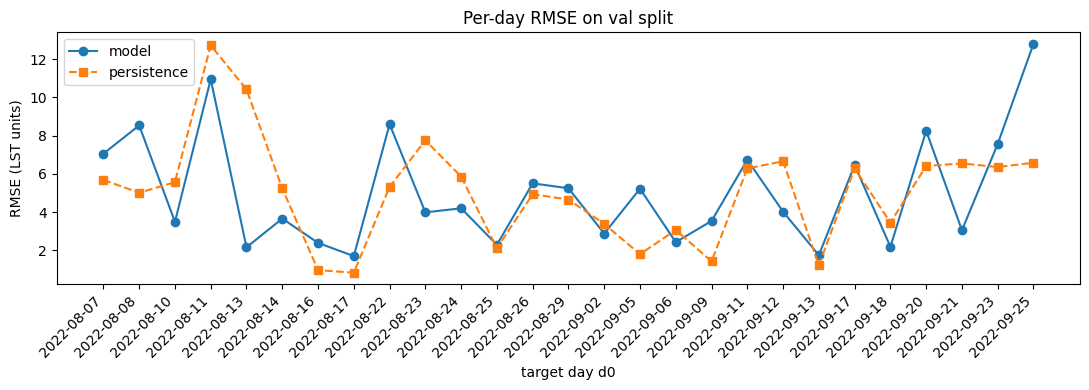

In [13]:
# --- Chart 1: per-day RMSE, model vs persistence -------------------------------------
piv = out.pivot_table(index="d0", columns="what", values="rmse").sort_index()

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(piv.index, piv["model"], "o-", label="model")
if "persistence" in piv:
    ax.plot(piv.index, piv["persistence"], "s--", label="persistence")
ax.set_ylabel("RMSE (LST units)"); ax.set_xlabel("target day d0")
ax.set_title(f"Per-day RMSE on {SPLIT} split"); ax.legend()
plt.xticks(rotation=45, ha="right"); plt.tight_layout(); plt.show()

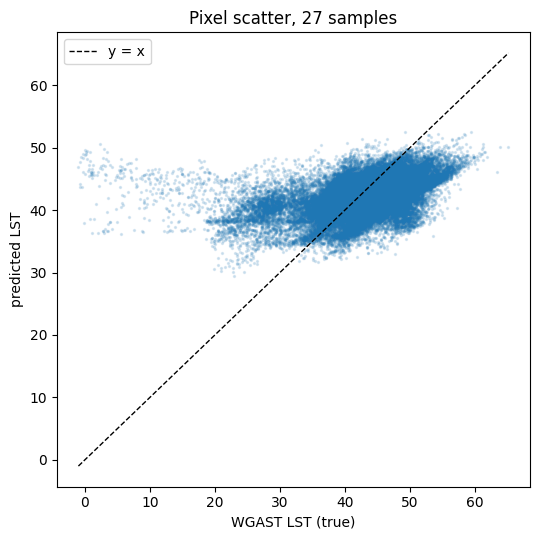

In [14]:
# --- Chart 2: predicted vs true LST (pixel scatter) ----------------------------------
rng = np.random.default_rng(0)
xs, ys = [], []
for r in rasters.values():
    flat_t = r["target"].ravel().astype(np.float32)
    flat_p = r["pred"].ravel().astype(np.float32)
    take = rng.choice(flat_t.size, size=min(2000, flat_t.size), replace=False)
    xs.append(flat_t[take]); ys.append(flat_p[take])
xs, ys = np.concatenate(xs), np.concatenate(ys)

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(xs, ys, s=2, alpha=0.15)
lo, hi = min(xs.min(), ys.min()), max(xs.max(), ys.max())
ax.plot([lo, hi], [lo, hi], "k--", lw=1, label="y = x")
ax.set_xlabel("WGAST LST (true)"); ax.set_ylabel("predicted LST")
ax.set_title(f"Pixel scatter, {len(rasters)} samples"); ax.legend()
plt.tight_layout(); plt.show()

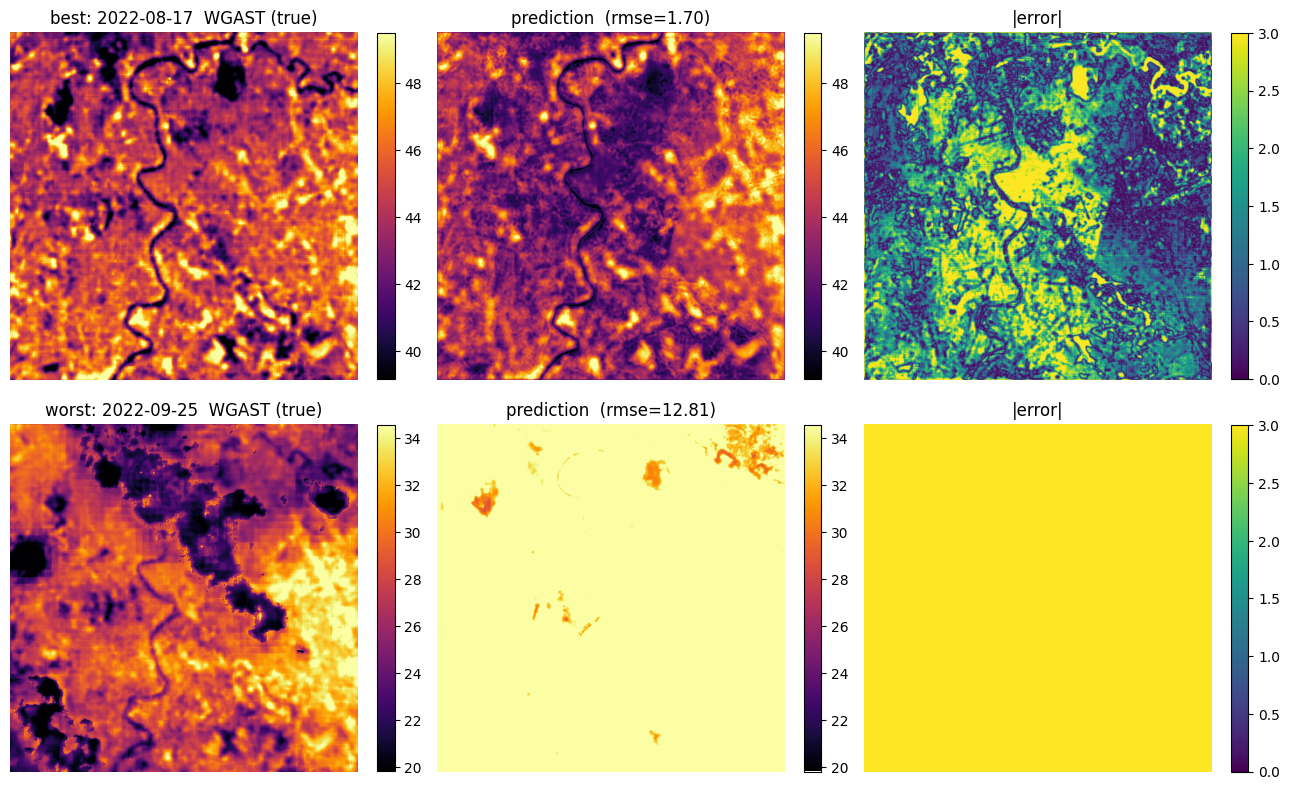

In [15]:
# --- Chart 3: maps for the best and worst day ----------------------------------------
by_rmse = (out[out["what"] == "model"].set_index("d0")["rmse"].sort_values())
picks = [("best", by_rmse.index[0]), ("worst", by_rmse.index[-1])]

fig, axes = plt.subplots(2, 3, figsize=(13, 8))
for row, (label, d0) in enumerate(picks):
    r = rasters[d0]
    t, p = r["target"].astype(np.float32), r["pred"].astype(np.float32)
    vmin, vmax = np.percentile(t, 2), np.percentile(t, 98)
    im0 = axes[row, 0].imshow(t, vmin=vmin, vmax=vmax, cmap="inferno")
    axes[row, 0].set_title(f"{label}: {d0}  WGAST (true)")
    im1 = axes[row, 1].imshow(p, vmin=vmin, vmax=vmax, cmap="inferno")
    axes[row, 1].set_title(f"prediction  (rmse={by_rmse[d0]:.2f})")
    im2 = axes[row, 2].imshow(np.abs(p - t), vmin=0, vmax=3, cmap="viridis")
    axes[row, 2].set_title("|error|")
    for ax_, im_ in zip(axes[row], (im0, im1, im2)):
        ax_.axis("off")
        fig.colorbar(im_, ax=ax_, fraction=0.045)
plt.tight_layout(); plt.show()

In [16]:
# --- Per-sample table (for the appendix / debugging) ---------------------------------
display(out.sort_values(["d0", "what"]).reset_index(drop=True).round(3))

,d0,city,what,rmse,mae,bias,psnr,ssim
0,2022-08-07,rome,model,7.058,6.386,-6.374,11.650,0.723
1,2022-08-07,rome,persistence,5.683,5.523,5.523,13.531,0.991
2,2022-08-08,rome,model,8.535,8.400,-8.400,10.702,0.915
3,2022-08-08,rome,persistence,5.011,4.851,-4.851,15.328,0.993
4,2022-08-10,rome,model,3.490,3.055,-2.953,18.283,0.925
5,2022-08-10,rome,persistence,5.571,5.413,5.413,14.220,0.992
6,2022-08-11,rome,model,10.950,5.253,3.340,14.673,0.920
7,2022-08-11,rome,persistence,12.725,6.721,6.377,13.369,0.930
8,2022-08-13,rome,model,2.157,1.771,0.836,20.177,0.902
9,2022-08-13,rome,persistence,10.418,6.903,1.073,6.499,0.908
